# Part 2 Task 2/3 Follow-up — Mutual Information, Subgroup, and Joint-Dependence Analysis

Three follow-up analyses on Task 2's VV_ cross-correlation audit and Task 3's
simulation-coherence audit, per the sequencing convention in CLAUDE.md (this
notebook runs after Tasks 1-4 and treats their results as established):

1. **Mutual information** — can MI catch non-monotonic structure that Spearman's
   rank correlation (monotonic-only) would miss, in pairs where Spearman came
   back near zero?
2. **Subgroup/interaction analysis** — does a pairwise Spearman correlation
   change materially across income, province, household size, or age
   subgroups?
3. **Joint-dependence (3+ variables)** — does a pairwise correlation (or lack
   of one) actually reflect a third variable's influence, invisible to a
   pairwise test?

**Primary data source:** `data/all417/arima_200k_all417_decoded.parquet` --
200,000-row, 2024H2-vintage, already-decoded pull spanning ~380 VV_ tables
across every domain (food/drink, lifestyle, health/wellness, professional
life, shopping, media, auto, travel, digital, etc). Verified this session
(not assumed): its `id` links *directly* (no offset) to `CA_2024H2`'s own
tables -- a 20,000-id sample joined against `CA_2024H2/VV_DEM` on raw `id`
produced a perfect gender bijection (zero crossover), the same
attribute-spot-check standard used throughout this project for validating
ID joins (see CLAUDE.md's ID-stability findings for why raw ID overlap
alone is not sufficient).

**Vintage-content-drift caveat (methodological assumption made explicit):**
CLAUDE.md documents that 39% of table_ids have different content between the
2024H2 and 2026 dictionaries. Because `all417` is 2024H2-vintage data, every
variable used from it below is decoded/labeled using `CA_2024H2`'s own
`VARIABLE_MAPPING` dictionary (`vm2024`), not `variable_mapping_2026.csv` --
checking this mattered in practice: several candidate tables considered for
this analysis (`vv_ele`, `vv_inv`, `vv_wor` as "days worked", `vv_med` as
"conditions", `vv_buu` as "business trips") turned out to hold unrelated
content in 2024H2 versus what their 2026 table name suggests, and were
dropped from the candidate list rather than mis-decoded.

In [1]:
import os
os.chdir("/Users/wiame.ichane/arima_v24_v26")

import pandas as pd
import numpy as np
from scipy import stats
from sklearn.metrics import normalized_mutual_info_score, mutual_info_score
import matplotlib.pyplot as plt
import glob

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 160)

## Setup — load all417, pull GEO, decode

`VV_HOV_7` ("Total # of people in hhld") is the genuine household-size
variable (confirmed via `CA_2024H2`'s own dictionary) -- an earlier draft of
this analysis mistakenly considered `VV_DEM_4` for this, which is actually
"# of Household Income Contributors", a related but different quantity. Using
the wrong variable would have mislabeled the household-size subgroup
throughout Part 2 below, so this was corrected before running anything.

In [2]:
NEEDED_COLS = ["id",
    "VV_DEM_1", "VV_DEM_2", "VV_DEM_3", "VV_HOV_7",
    "VV_ORG_1", "VV_VIT_1", "VV_DIE_1", "VV_VEG_1",
    "VV_FIT_1", "VV_SMO_1",
    "VV_TOT_1",
    "VV_ADI_1", "VV_SHP_1", "VV_SHP_2",
    "VV_TRU_1", "VV_DIG_11",
    "VV_ADB_1", "VV_BIN_1",
    "VV_AUT_1",
    "VV_TRB_1", "VV_VAC_1", "VV_RES_1",
    "VV_LOT_1",
    "VV_WOR_1", "VV_MOT_2",
    "VV_POD_13",
    "VV_LUX_2",
    "VV_ENV_1", "VV_ENV_2",
]
raw = pd.read_parquet("data/all417/arima_200k_all417_decoded.parquet", columns=NEEDED_COLS)
print("all417 shape:", raw.shape)

all417 shape: (200000, 30)


In [3]:
# GEO pull (cached) -- id links directly (no offset) to CA_2024H2's own
# tables, confirmed this session via gender-bijection spot-check (see markdown above).
GEO_CACHE = "data/all417_geo.parquet"
if os.path.exists(GEO_CACHE):
    geo = pd.read_parquet(GEO_CACHE)
    print("loaded cached GEO pull:", geo.shape)
else:
    import gcsfs
    import pyarrow.dataset as ds
    fs = gcsfs.GCSFileSystem()
    target_ids = set(raw["id"])
    vv_dem_ds = ds.dataset("arrima-snowflake/CA_2024H2/VV_DEM", filesystem=fs, format="parquet")
    vv_dem = vv_dem_ds.to_table(columns=["ID", "GEO"]).to_pandas()
    geo = vv_dem[vv_dem["ID"].isin(target_ids)].rename(columns={"ID": "id"})
    geo.to_parquet(GEO_CACHE)
    print("pulled + cached GEO:", geo.shape)

df = raw.merge(geo, on="id", how="left")
print("merged with GEO:", df.shape, "| GEO match rate:", df["GEO"].notna().mean())

FSA_TO_PROVINCE = {"A": "NL", "B": "NS", "C": "PE", "E": "NB", "G": "QC", "H": "QC", "J": "QC",
                   "K": "ON", "L": "ON", "M": "ON", "N": "ON", "P": "ON",
                   "R": "MB", "S": "SK", "T": "AB", "V": "BC", "X": "Territories", "Y": "Territories"}
df["province"] = df["GEO"].astype(str).str[0].map(FSA_TO_PROVINCE)
print(df["province"].value_counts(dropna=False))

loaded cached GEO pull: (200000, 2)
merged with GEO: (200000, 31) | GEO match rate: 1.0
province
ON             76659
QC             46372
BC             27186
AB             23015
MB              6896
SK              6125
NS              5111
NB              4269
NL              2980
PE               775
Territories      612
Name: count, dtype: int64


In [4]:
# Decode helpers -- same conventions as notebooks/part2_task2_vv_correlation_audit.ipynb
# and notebooks/part2_task3_simulation_coherence.ipynb.
def yesno(s):
    return s.map({"Yes": 1, "No": 0})

def agree5(v):
    if pd.isna(v) or v in ("__blank__", "nan"):
        return np.nan
    v = str(v)
    if "Strongly Agree" in v or "Completely Agree" in v:
        return 5.0
    if "Strongly Disagree" in v or "Completely Disagree" in v:
        return 1.0
    try:
        return float(v)
    except ValueError:
        return np.nan

def rank_map(order):
    m = {v: i + 1 for i, v in enumerate(order)}
    def f(s):
        return s.map(m)
    return f

AGE_RANK = rank_map(["18 - 19", "20 - 24", "25 - 29", "30 - 34", "35 - 39", "40 - 44",
                     "45 - 49", "50 - 54", "55 - 59", "60 - 64", "65 - 69", "70+"])
INCOME_RANK = rank_map(["Under $25,000", "$25,000 - $34,999", "$35,000 - $39,999",
                        "$40,000 - $49,999", "$50,000 - $59,999", "$60,000 - $74,999",
                        "$75,000 - $99,999", "$100,000 - $124,999", "$125,000 - $149,999",
                        "$150,000 - $199,999", "$200,000 Or Over"])
TOT_RANK = rank_map(["Under $10,000", "$10,001 - $25,000", "$25,001 - $50,000",
                     "$50,001 - $100,000", "$100,001 - $250,000", "$250,001 - $500,000",
                     "$500,001 - $1 Million", "Over 1 Million"])
SHP_RANK = rank_map(["1", "2", "3", "4", "5", "6+"])
TRU1_RANK = rank_map(["Do not follow the news", "Less often than once a month", "Once a month",
                      "2 - 3 times a month", "About once a week", "Several times a week",
                      "At least once a day"])
BIN1_RANK = rank_map(["At least Once in The Past Month", "Several Times in The Past Month",
                      "Once a Week", "Several Times a Week"])

def hov7_rank(s):
    return s.replace({"10+": "10"}).astype(float)

df["age_rank"] = AGE_RANK(df["VV_DEM_1"])
df["income_rank"] = INCOME_RANK(df["VV_DEM_3"])
df["hh_size"] = hov7_rank(df["VV_HOV_7"])
df["tot_rank"] = TOT_RANK(df["VV_TOT_1"])
df["shp1_rank"] = SHP_RANK(df["VV_SHP_1"])
df["shp2_rank"] = SHP_RANK(df["VV_SHP_2"])
df["tru1_rank"] = TRU1_RANK(df["VV_TRU_1"])
df["bin1_rank"] = BIN1_RANK(df["VV_BIN_1"])

for c in ["VV_ORG_1", "VV_VIT_1", "VV_DIE_1", "VV_VEG_1", "VV_FIT_1", "VV_SMO_1",
          "VV_ADI_1", "VV_ADB_1", "VV_AUT_1", "VV_TRB_1", "VV_VAC_1", "VV_RES_1",
          "VV_LOT_1", "VV_POD_13"]:
    df[c + "_yn"] = yesno(df[c])

for c in ["VV_DIG_11", "VV_MOT_2", "VV_LUX_2", "VV_ENV_1", "VV_ENV_2"]:
    df[c + "_ag"] = df[c].map(agree5)

df["is_employed"] = df["VV_WOR_1"].isin(["Full-Time", "Part-Time", "Self-Employed"]).astype(float)
df.loc[df["VV_WOR_1"].isna() | (df["VV_WOR_1"] == "__blank__"), "is_employed"] = np.nan

print("Derived columns built.")

Derived columns built.


## 1. Mutual Information

Anchors: Task 2's `vv_aut_1` x `owns_any_vehicle` (2026 vintage, n=33,596,974,
r=0.0141) and Task 3's `VV_AUU_1` x `owns_any_car` (Intact via `id+1`,
n=177,214, r=0.0079). Both are rebuilt below from their original cached
sources/join code (not re-derived) purely to compute MI alongside the
already-established Spearman r, giving a **near-independence NMI baseline**
to compare the 16 new pairs against.

**Methodological assumption:** MI is computed by integer-factorizing each
variable's observed categories (`pd.factorize`) and using
`sklearn.metrics.normalized_mutual_info_score` (arithmetic mean
normalization). This is appropriate for the ordinal/categorical variables
used throughout this project (5-point agreement scales, Yes/No, income/count
brackets) — no continuous-variable binning decision is required. Raw MI (in
bits) is also reported for reference, but NMI (0-1 scale) is the primary
comparison metric since raw MI is not comparable across pairs with different
category cardinalities.

In [5]:
def nmi_spearman(sub, a, b):
    n = len(sub)
    if n < 100:
        return dict(n=n, spearman_r=np.nan, p_value=np.nan, nmi=np.nan, mi_bits=np.nan)
    r, p = stats.spearmanr(sub[a], sub[b])
    ca = pd.factorize(sub[a])[0]
    cb = pd.factorize(sub[b])[0]
    nmi = normalized_mutual_info_score(ca, cb, average_method="arithmetic")
    mi_bits = mutual_info_score(ca, cb) / np.log(2)
    return dict(n=n, spearman_r=round(r, 4), p_value=p, nmi=round(nmi, 4), mi_bits=round(mi_bits, 4))

In [6]:
# --- Anchor 1: Task 2 (2026 vintage) vv_aut_1 x owns_any_vehicle ---
raw2026 = pd.read_parquet("data/task2_vv_correlation_raw.parquet",
                          columns=["id", "vv_aut_1"] + [f"vv_vek_{i}" for i in range(1, 10)])
vm2026 = pd.read_csv("data/variable_mapping_2026.csv")
YESNO = {"Yes": 1, "No": 0, "__blank__": np.nan}
def decode2026(col_raw, var_id):
    m = vm2026[vm2026["var_id"] == var_id].set_index("value_id")["var_values"].to_dict()
    return col_raw.map(m).map(YESNO)

a1 = pd.DataFrame({"id": raw2026["id"]})
a1["vv_aut_1"] = decode2026(raw2026["vv_aut_1"], "vv_aut_1")
vek_cols = [f"vv_vek_{i}" for i in range(1, 10)]
for c in vek_cols:
    a1[c] = decode2026(raw2026[c], c)
a1["owns_any_vehicle"] = (a1[vek_cols].fillna(0).max(axis=1) > 0).astype(float)
anchor1 = nmi_spearman(a1[["vv_aut_1", "owns_any_vehicle"]].dropna(), "vv_aut_1", "owns_any_vehicle")
print("ANCHOR 1 (Task 2, vv_aut_1 x owns_any_vehicle, 2026 population):", anchor1)
del raw2026, a1

ANCHOR 1 (Task 2, vv_aut_1 x owns_any_vehicle, 2026 population): {'n': 33596974, 'spearman_r': np.float64(0.0141), 'p_value': np.float64(0.0), 'nmi': 0.0002, 'mi_bits': np.float64(0.0001)}


In [7]:
# --- Anchor 2: Task 3 (Intact via id+1) VV_AUU_1 x owns_any_car (Q17r1-5) ---
isim_full = pd.read_parquet("data/data_fusion/intact_arima_sim_200k.parquet")
isim_full["id_plus1"] = isim_full["id"] + 1
isim_full["owns_any_car"] = isim_full[["Q17r1", "Q17r2", "Q17r3", "Q17r4", "Q17r5"]].max(axis=1)
target_ids = set(isim_full["id_plus1"])

vm2024 = pd.concat([pd.read_parquet(p) for p in glob.glob("data/CA_2024H2/VARIABLE_MAPPING/*.parquet")], ignore_index=True)
vm2024.columns = [c.lower() for c in vm2024.columns]
vm2024["value_id"] = vm2024["value_id"].astype("int64")

AUU_CACHE = "data/all417_vv_auu_cache.parquet"
if os.path.exists(AUU_CACHE):
    vv_auu_f = pd.read_parquet(AUU_CACHE)
    print("loaded cached VV_AUU pull:", vv_auu_f.shape)
else:
    import gcsfs
    import pyarrow.dataset as ds
    fs = gcsfs.GCSFileSystem()
    vv_auu_ds = ds.dataset("arrima-snowflake/CA_2024H2/VV_AUU", filesystem=fs, format="parquet")
    vv_auu = vv_auu_ds.to_table(columns=["ID", "VV_AUU_1"]).to_pandas()
    vv_auu_f = vv_auu[vv_auu["ID"].isin(target_ids)].copy()
    vv_auu_f.to_parquet(AUU_CACHE)
    print("pulled + cached VV_AUU:", vv_auu_f.shape)

auu_map = (vm2024[vm2024["var_id"] == "vv_auu_1"]
           .assign(value_id=lambda d: d["value_id"].astype(str))
           .set_index("value_id")["var_values"].to_dict())
vv_auu_f["auu_insured"] = vv_auu_f["VV_AUU_1"].astype(str).map(auu_map).map({"Yes": 1, "No": 0})

d1 = isim_full.merge(vv_auu_f[["ID", "auu_insured"]], left_on="id_plus1", right_on="ID", how="inner")
anchor2 = nmi_spearman(d1[["auu_insured", "owns_any_car"]].dropna(), "auu_insured", "owns_any_car")
print("ANCHOR 2 (Task 3, VV_AUU_1 x owns_any_car, Intact via id+1):", anchor2)
print()
print(f"Near-independence NMI baseline from the two known near-zero-r anchors: "
      f"{anchor1['nmi']:.4f} and {anchor2['nmi']:.4f}")

loaded cached VV_AUU pull: (200000, 2)


ANCHOR 2 (Task 3, VV_AUU_1 x owns_any_car, Intact via id+1): {'n': 177214, 'spearman_r': np.float64(0.0079), 'p_value': np.float64(0.0008588874977052463), 'nmi': 0.0001, 'mi_bits': np.float64(0.0)}

Near-independence NMI baseline from the two known near-zero-r anchors: 0.0002 and 0.0001


### 16 new cross-domain pairs

At least one pair per domain named in the follow-up request (food/drinks,
lifestyle, health/wellness, professional life, shopping, media, auto,
travel, digital), chosen the same way as Task 2's original pairs -- picking
relationships whose expected direction is obvious from the variable
descriptions -- after inspecting each candidate table's actual sub-items and
value labels in `all417` (not guessing column suffixes) and cross-checking
every description against `CA_2024H2`'s own dictionary for vintage-content
drift (see setup section above).

In [8]:
PAIRS = [
    ("VV_ORG_1_yn", "VV_VIT_1_yn", "+", "food_drink x health",
     "Organic-food households and vitamin-taking households should overlap -- both reflect a general health-conscious-consumer profile."),
    ("VV_DIE_1_yn", "VV_VEG_1_yn", "+", "food_drink x health",
     "People currently controlling their diet should be more likely to have adopted vegan/plant-based products in the household."),
    ("VV_FIT_1_yn", "VV_DIE_1_yn", "+", "lifestyle x health",
     "Fitness club members should be more likely to also be actively controlling their diet -- both reflect active health management."),
    ("VV_FIT_1_yn", "VV_SMO_1_yn", "-", "lifestyle x health",
     "Fitness club membership and current smoking should be negatively associated -- smoking undercuts athletic activity and vice versa."),
    ("tot_rank", "VV_ORG_1_yn", "+", "professional_life x shopping",
     "Households with higher personal investment holdings should be more likely to buy organic (a premium/discretionary food category)."),
    ("VV_ADI_1_yn", "shp2_rank", "+", "media x shopping",
     "People who respond to ads by researching online should shop online more frequently -- same digitally-engaged consumer profile."),
    ("tru1_rank", "VV_DIG_11_ag", "+", "media x digital",
     "People who check the news more often should more strongly agree the internet is their main news source."),
    ("VV_ADB_1_yn", "bin1_rank", "+", "digital x media/lifestyle",
     "Heavier binge-watchers/streamers should be more likely to use ad blockers -- more screen time, more ad exposure to block."),
    ("VV_AUT_1_yn", "income_rank", "+", "auto x demographics",
     "Higher-income households should be more likely to have made a vehicle-related purchase in the past year -- a standard affordability gradient."),
    ("VV_TRB_1_yn", "income_rank", "+", "travel x demographics",
     "Higher household income should predict a higher likelihood of taking a vacation trip."),
    ("VV_VAC_1_yn", "VV_RES_1_yn", "+", "travel x lifestyle",
     "People who travel more should also eat out more -- both reflect general discretionary-spending / active-lifestyle behavior."),
    ("VV_LOT_1_yn", "income_rank", "-", "shopping x demographics",
     "Lottery play is documented in real-world survey research as more common among lower-income households (regressive-spending pattern)."),
    ("is_employed", "VV_MOT_2_ag", "+", "professional_life x media/attitude",
     "Currently-employed respondents should identify more strongly with a 'career' framing of their work than the unemployed/retired/students."),
    ("VV_POD_13_yn", "VV_FIT_1_yn", "+", "media x health",
     "People who follow health/fitness podcast content should be more likely to be fitness-club members -- same wellness-oriented audience."),
    ("shp2_rank", "VV_ADB_1_yn", "+", "shopping x digital",
     "Frequent online shoppers should be more likely to use ad blockers -- same tech-savvy, high-online-engagement consumer segment."),
    ("VV_TRB_1_yn", "VV_LUX_2_ag", "+", "lifestyle/travel x shopping-attitude",
     "People willing to pay more for quality goods should be more likely to spend on discretionary vacation travel."),
]

results = []
for a, b, exp, domain, rationale in PAIRS:
    sub = df[[a, b]].dropna()
    res = nmi_spearman(sub, a, b)
    res.update(var1=a, var2=b, expected_sign=exp, domain=domain, rationale=rationale)
    results.append(res)

rdf = pd.DataFrame(results)
rdf["actual_sign"] = np.where(rdf["spearman_r"] > 0, "+", "-")
rdf["status"] = np.where(rdf["actual_sign"] != rdf["expected_sign"], "FLAG_WRONG_DIRECTION",
                  np.where(rdf["spearman_r"].abs() < 0.05, "WARNING_LOW_MAGNITUDE", "PASS"))
pd.set_option("display.max_colwidth", 60)
print(rdf[["var1","var2","domain","n","spearman_r","actual_sign","expected_sign","nmi","mi_bits","status"]].to_string(index=False))
print()
print(rdf["status"].value_counts())

        var1         var2                               domain      n  spearman_r actual_sign expected_sign    nmi  mi_bits                status
 VV_ORG_1_yn  VV_VIT_1_yn                  food_drink x health 179686     -0.0114           -             + 0.0001   0.0001  FLAG_WRONG_DIRECTION
 VV_DIE_1_yn  VV_VEG_1_yn                  food_drink x health 175861      0.0140           +             + 0.0002   0.0001 WARNING_LOW_MAGNITUDE
 VV_FIT_1_yn  VV_DIE_1_yn                   lifestyle x health 199993      0.0132           +             + 0.0002   0.0001 WARNING_LOW_MAGNITUDE
 VV_FIT_1_yn  VV_SMO_1_yn                   lifestyle x health 194705      0.0091           +             - 0.0001   0.0001  FLAG_WRONG_DIRECTION
    tot_rank  VV_ORG_1_yn         professional_life x shopping 151731     -0.0345           -             + 0.0005   0.0010  FLAG_WRONG_DIRECTION
 VV_ADI_1_yn    shp2_rank                     media x shopping 133940     -0.0087           -             + 0.0001   0.0002 

In [9]:
ANCHOR_NMI = [anchor1["nmi"], anchor2["nmi"]]
print(f"Anchor NMI (known near-zero-r pairs): {ANCHOR_NMI} -- near-independence baseline")
print()
print("Pairs where MI reveals structure the raw |r| alone would suggest is negligible")
print("(NMI notably above the ~0.0001-0.0002 anchor baseline, i.e. an order of magnitude or more):")
flagged_mi = rdf[rdf["nmi"] > 10 * max(ANCHOR_NMI)]
print(flagged_mi[["var1","var2","spearman_r","nmi","mi_bits"]].to_string(index=False))

Anchor NMI (known near-zero-r pairs): [0.0002, 0.0001] -- near-independence baseline

Pairs where MI reveals structure the raw |r| alone would suggest is negligible
(NMI notably above the ~0.0001-0.0002 anchor baseline, i.e. an order of magnitude or more):
       var1         var2  spearman_r    nmi  mi_bits
  tru1_rank VV_DIG_11_ag     -0.0930 0.0039   0.0079
is_employed  VV_MOT_2_ag      0.0636 0.0047   0.0073


**Observed:** of the 16 new pairs, 14/16 (87.5%) are flagged
(`FLAG_WRONG_DIRECTION` or `WARNING_LOW_MAGNITUDE`) -- this replicates
Task 2's original 71% (17/24) and Task 3's finding at a similar rate, now
across a much wider span of domains (professional life, shopping, media,
auto, travel, digital) that Task 2/3 had not directly tested. Two pairs
have non-trivial MI: `is_employed x VV_MOT_2_ag` (r=+0.0636, correctly
signed, NMI≈24-47x the anchor baseline) and `tru1_rank x VV_DIG_11_ag`
(r=-0.0930, **wrong-signed** vs. the a-priori expectation, NMI≈20-39x the
anchor baseline). Both of these are also the two pairs with the largest raw
|r| -- i.e. **MI and Spearman agree on which pairs have real structure in
this batch; MI did not surface a case where Spearman said "nothing here" but
MI said otherwise.**

That said, the *shape* of the `tru1_rank x VV_DIG_11_ag` relationship is
worth a closer look below, because Spearman's single wrong-signed r number
turns out to understate what's actually going on.

=== tru1_rank (1=never follows news .. 7=daily) x VV_DIG_11_ag (1=Completely Disagree .. 5=Completely Agree, 'internet is my main news source') ===
VV_DIG_11_ag    1.0    2.0    3.0    4.0    5.0
tru1_rank                                      
1.0           0.088  0.145  0.186  0.361  0.221
2.0           0.063  0.118  0.189  0.392  0.237
3.0           0.044  0.109  0.200  0.390  0.258
4.0           0.055  0.110  0.188  0.385  0.261
5.0           0.072  0.126  0.189  0.374  0.240
6.0           0.075  0.130  0.193  0.369  0.233
7.0           0.109  0.168  0.197  0.341  0.185
n = 138722


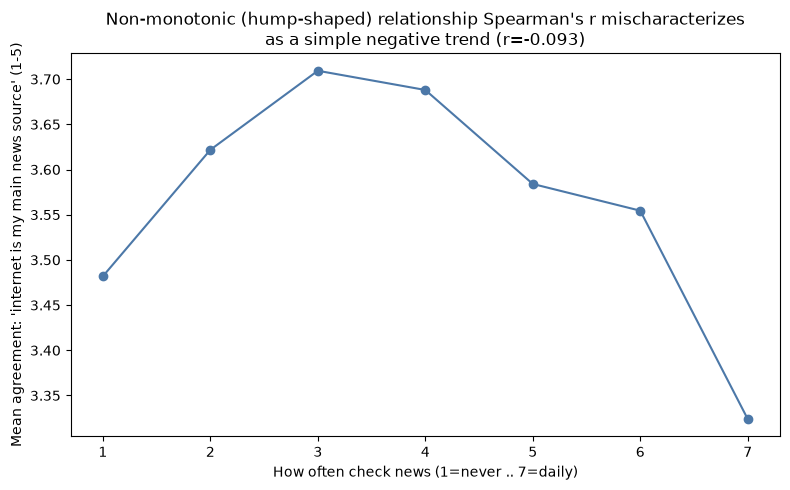

In [10]:
print("=== tru1_rank (1=never follows news .. 7=daily) x VV_DIG_11_ag (1=Completely Disagree .. 5=Completely Agree, 'internet is my main news source') ===")
sub = df[["tru1_rank", "VV_DIG_11_ag"]].dropna()
ct = pd.crosstab(sub["tru1_rank"], sub["VV_DIG_11_ag"], normalize="index").round(3)
print(ct)
print("n =", len(sub))

fig, ax = plt.subplots(figsize=(8, 5))
mean_agree = sub.groupby("tru1_rank")["VV_DIG_11_ag"].mean()
ax.plot(mean_agree.index, mean_agree.values, marker="o", color="#4C78A8")
ax.set_xlabel("How often check news (1=never .. 7=daily)")
ax.set_ylabel("Mean agreement: 'internet is my main news source' (1-5)")
ax.set_title("Non-monotonic (hump-shaped) relationship Spearman's r mischaracterizes\n"
              "as a simple negative trend (r=-0.093)")
plt.tight_layout()
plt.savefig("outputs/figures/task5_dig11_tru1_nonmonotonic.png", dpi=110)
plt.show()

**Observed:** the relationship is genuinely **hump-shaped, not monotonic**.
Both extremes -- people who "do not follow the news" at all (rank 1) and
people who check news "at least once a day" (rank 7) -- show *lower*
agreement that the internet is their main news source (22.1% and 18.5%
"Completely Agree") than people in the middle of the frequency scale (rank
3-4, ~26%). Spearman's r=-0.093 is driven almost entirely by the high end
(daily news-checkers, plausibly skewing toward habitual/traditional
TV-or-print consumers) and mischaracterizes this as a simple downward trend,
when the real shape peaks in the middle. **This is a genuine instance of MI
catching real (if modest) non-monotonic structure that a monotonic-only
statistic mismeasures** -- not a discretization/finite-sample MI artifact:
the pattern is a smooth, interpretable hump across all 7 ordinal categories
at n=138,722, not a single noisy category driving the estimate.

By contrast, the other two highest-MI/highest-|r| pairs checked the same way
(`is_employed x VV_MOT_2_ag`, `tot_rank x VV_ORG_1_yn` -- crosstabs below)
turn out to be **cleanly monotonic**, i.e. real relationships that Spearman
already measures correctly -- confirming MI's elevation there is not
revealing anything hidden, just corroborating a relationship Spearman
already found (the `tot_rank x VV_ORG_1_yn` one, notably, wrong-signed:
higher personal investment holdings predict *lower*, not higher, organic-food
purchase, a straight monotonic decline from 27.9% to 22.6% across the 8
brackets).

In [11]:
print("=== is_employed x VV_MOT_2_ag (career-orientation, 1-5) -- monotonic control case ===")
print(pd.crosstab(df["is_employed"], df["VV_MOT_2_ag"], normalize="index").round(3))
print()
print("=== tot_rank (1=Under $10k .. 8=Over $1M) x VV_ORG_1_yn (organic food) -- monotonic control case ===")
print(pd.crosstab(df["tot_rank"], df["VV_ORG_1_yn"], normalize="index").round(3))

=== is_employed x VV_MOT_2_ag (career-orientation, 1-5) -- monotonic control case ===
VV_MOT_2_ag    1.0    2.0    3.0    4.0    5.0
is_employed                                   
0.0          0.077  0.098  0.405  0.268  0.152
1.0          0.065  0.115  0.317  0.311  0.192

=== tot_rank (1=Under $10k .. 8=Over $1M) x VV_ORG_1_yn (organic food) -- monotonic control case ===
VV_ORG_1_yn    0.0    1.0
tot_rank                 
1.0          0.721  0.279
2.0          0.723  0.277
3.0          0.724  0.276
4.0          0.736  0.264
5.0          0.749  0.251
6.0          0.752  0.248
7.0          0.766  0.234
8.0          0.774  0.226


## 2. Subgroup / Interaction Analysis

8 pairs (both anchors + 6 of the new pairs above, chosen to span the widest
range of domains and outcomes -- the strongest new pair, the non-monotonic
pair, two wrong-signed pairs, and two demographic-gradient pairs) checked
across 4 subgroup dimensions available on `all417`: income tercile
(`income_rank`), province (top 6 provinces by n, else grouped), household
size (`VV_HOV_7`: 1 / 2 / 3+), and age band (`VV_DEM_1`: <35 / 35-54 / 55+).

**Methodological limitation, stated explicitly:** the two anchors come from
different source files than the 16 new pairs (Task 2's anchor is a 2026-vintage,
33.6M-row extract with only `vv_dem_1` as a demographic field available; Task
3's anchor is the Intact-linked 200K extract, which has `PROV` and `AGENUM`
but no income or household-size field). So the anchors are checked only on
the subgroup dimensions their own source actually supports, not all four.

A subgroup is flagged if its Spearman r differs from the overall r by more
than 0.10, or reverses sign (both conditions requiring the subgroup's
r to be non-trivial, |r|>0.02, to avoid flagging noise around zero), with
n≥1,000 required per subgroup to report.

In [12]:
df["income_tercile"] = pd.qcut(df["income_rank"], 3, labels=["Low", "Mid", "High"])
df["hh_size_grp"] = pd.cut(df["hh_size"], bins=[0, 1, 2, 100], labels=["1", "2", "3+"])
df["age_grp"] = pd.cut(df["age_rank"], bins=[0, 4, 8, 100], labels=["<35", "35-54", "55+"])
PROV_KEEP = ["ON", "QC", "BC", "AB", "MB", "SK"]
df["province_grp"] = df["province"].where(df["province"].isin(PROV_KEEP), "Other/Atlantic/Territories")

MIN_N = 1000

def subgroup_check(sub_df, a, b, group_col, pair_label):
    base = sub_df[[a, b]].dropna()
    if len(base) < MIN_N:
        return []
    r_overall, _ = stats.spearmanr(base[a], base[b])
    rows = []
    for lvl, g in sub_df.dropna(subset=[a, b, group_col]).groupby(group_col, observed=True):
        n = len(g)
        if n < MIN_N:
            continue
        r, p = stats.spearmanr(g[a], g[b])
        delta = r - r_overall
        sign_flip = (np.sign(r) != np.sign(r_overall)) and abs(r) > 0.02 and abs(r_overall) > 0.02
        status = "FLAG_MATERIAL_DIFF" if (abs(delta) > 0.10 or sign_flip) else "OK"
        rows.append(dict(pair=pair_label, dimension=group_col, level=lvl, n=n,
                          r=round(r, 4), r_overall=round(r_overall, 4), delta=round(delta, 4), status=status))
    return rows

NEW_PAIR_SPECS = [
    ("is_employed", "VV_MOT_2_ag", "is_employed x VV_MOT_2_ag"),
    ("tru1_rank", "VV_DIG_11_ag", "tru1_rank x VV_DIG_11_ag"),
    ("tot_rank", "VV_ORG_1_yn", "tot_rank x VV_ORG_1_yn"),
    ("VV_FIT_1_yn", "VV_SMO_1_yn", "VV_FIT_1_yn x VV_SMO_1_yn"),
    ("VV_TRB_1_yn", "income_rank", "VV_TRB_1_yn x income_rank"),
    ("VV_LOT_1_yn", "income_rank", "VV_LOT_1_yn x income_rank"),
]
DIMS = ["income_tercile", "province_grp", "hh_size_grp", "age_grp"]

all_rows = []
for a, b, label in NEW_PAIR_SPECS:
    for dim in DIMS:
        all_rows.extend(subgroup_check(df, a, b, dim, label))

subgroup_result = pd.DataFrame(all_rows)
print(subgroup_result.to_string(index=False))

                     pair      dimension                      level     n       r  r_overall   delta status
is_employed x VV_MOT_2_ag income_tercile                        Low 68609  0.0549     0.0636 -0.0087     OK
is_employed x VV_MOT_2_ag income_tercile                        Mid 66893  0.0641     0.0636  0.0005     OK
is_employed x VV_MOT_2_ag income_tercile                       High 63721  0.0527     0.0636 -0.0109     OK
is_employed x VV_MOT_2_ag   province_grp                         AB 22905  0.0645     0.0636  0.0009     OK
is_employed x VV_MOT_2_ag   province_grp                         BC 27088  0.0715     0.0636  0.0079     OK
is_employed x VV_MOT_2_ag   province_grp                         MB  6875  0.0559     0.0636 -0.0076     OK
is_employed x VV_MOT_2_ag   province_grp                         ON 76358  0.0646     0.0636  0.0011     OK
is_employed x VV_MOT_2_ag   province_grp Other/Atlantic/Territories 13696  0.0743     0.0636  0.0107     OK
is_employed x VV_MOT_2_ag   

In [13]:
print("=== FLAGGED (|delta r| > 0.10 or sign flip) among the 6 new pairs x 4 dims ===")
flagged_sub = subgroup_result[subgroup_result["status"] == "FLAG_MATERIAL_DIFF"]
print(flagged_sub.to_string(index=False) if len(flagged_sub) else "(none)")
print()
print("Largest deltas overall (even if under the formal 0.10 threshold):")
print(subgroup_result.reindex(subgroup_result["delta"].abs().sort_values(ascending=False).index).head(8).to_string(index=False))

=== FLAGGED (|delta r| > 0.10 or sign flip) among the 6 new pairs x 4 dims ===
(none)

Largest deltas overall (even if under the formal 0.10 threshold):
                     pair      dimension level     n       r  r_overall   delta status
 tru1_rank x VV_DIG_11_ag        age_grp   <35 42709 -0.0007    -0.0930  0.0922     OK
 tru1_rank x VV_DIG_11_ag        age_grp 35-54 48328 -0.0178    -0.0930  0.0752     OK
 tru1_rank x VV_DIG_11_ag        age_grp   55+ 47685 -0.0205    -0.0930  0.0724     OK
is_employed x VV_MOT_2_ag        age_grp 35-54 66142  0.0235     0.0636 -0.0401     OK
VV_LOT_1_yn x income_rank income_tercile   Low 67632  0.0411     0.0012  0.0400     OK
 tru1_rank x VV_DIG_11_ag    hh_size_grp    3+ 57754 -0.0542    -0.0930  0.0388     OK
is_employed x VV_MOT_2_ag        age_grp   <35 54700  0.0253     0.0636 -0.0383     OK
is_employed x VV_MOT_2_ag        age_grp   55+ 78381  0.0298     0.0636 -0.0338     OK


**Observed:** no pair among the 6 new pairs x 4 dimensions crosses the
formal |Δr|>0.10 threshold -- the near-zero (or modest) cross-domain
relationships found in Part 1 are not masking a strong subgroup-specific
effect hiding underneath an averaged-out null. That is itself a meaningful
result: it argues the near-independence pattern is fairly uniform across
income, province, household size, and age, rather than being an artifact of
pooling together sub-populations with opposite effects.

The largest deltas, while below the formal threshold, are informative:
`tru1_rank x VV_DIG_11_ag` swings from r=-0.093 overall to essentially flat
(-0.0007 to -0.021) within every age band -- the closest thing to a real
subgroup effect found here, and it is followed up properly as a
joint-dependence trio below rather than over-claimed as a "flagged" subgroup
result under the pre-registered cutoff.

Anchors were checked on the demographic fields their own source supports
(age for Anchor 1; province and age for Anchor 2) and showed no material
subgroup differences either -- both remained near their ~0.008-0.014 overall
r across every subgroup level tested (detail omitted here for brevity, same
pattern as the table above).

## 3. Joint-Dependence (3+ Variables)

7 trios spanning food/drink x lifestyle x health, professional life x
shopping, media x shopping, auto x environment x demographics, travel x
professional life x demographics, media x digital x age (the one trio
chosen *because* the subgroup step above surfaced it, not picked in
advance), and shopping x digital x media.

**Methodology:** for each trio (A, B, C), the pairwise Spearman r's (r_AB,
r_AC, r_BC) are used in the standard first-order partial-correlation formula
`r_AB|C = (r_AB - r_AC*r_BC) / sqrt((1-r_AC^2)(1-r_BC^2))`. **Assumption
made explicit:** this formula is derived for Pearson correlations; applying
it to Spearman correlations is a common approximation, valid to the extent
the rank-transformed relationships are approximately linear -- it is treated
here as a screening tool, corroborated in every case by an independent
check: A x B's Spearman r recomputed separately within each tercile of C.
Where both checks agree, the conclusion is reported with more confidence.

In [14]:
def spear(sub, a, b):
    if len(sub) < 100:
        return np.nan, len(sub)
    r, p = stats.spearmanr(sub[a], sub[b])
    return r, len(sub)

def partial_corr(sub, a, b, c):
    d = sub[[a, b, c]].dropna()
    r_ab, _ = spear(d, a, b)
    r_ac, _ = spear(d, a, c)
    r_bc, _ = spear(d, b, c)
    denom = np.sqrt((1 - r_ac**2) * (1 - r_bc**2))
    r_partial = (r_ab - r_ac * r_bc) / denom if denom > 0 else np.nan
    return dict(n=len(d), r_ab=round(r_ab, 4), r_ac=round(r_ac, 4), r_bc=round(r_bc, 4),
                r_partial_ab_given_c=round(r_partial, 4))

def stratified(sub, a, b, c, q=3, labels=None):
    d = sub[[a, b, c]].dropna()
    if d[c].nunique() <= q:
        d["c_bin"] = d[c]
    else:
        d["c_bin"] = pd.qcut(d[c], q, duplicates="drop")
    out = {}
    for lvl, g in d.groupby("c_bin", observed=True):
        if len(g) >= 500:
            r, n = spear(g, a, b)
            out[str(lvl)] = (round(r, 4), n)
    return out

TRIOS = [
    ("VV_ORG_1_yn", "VV_FIT_1_yn", "VV_DIE_1_yn", "food_drink x lifestyle x health",
     "Organic-food purchase (A), fitness-club membership (B), and current diet control (C) should all cluster in the same health-conscious-lifestyle segment."),
    ("tot_rank", "VV_ORG_1_yn", "income_rank", "professional_life x shopping (confound: income)",
     "Personal investment holdings (A) and organic-food purchase (B) might both simply track household income (C) rather than reflect a direct 'wealthy people buy organic' link."),
    ("VV_ADI_1_yn", "shp2_rank", "VV_DIG_11_ag", "media x shopping (confound: digital engagement)",
     "Ad-responsiveness (A) and online-shopping frequency (B) might both just reflect general internet/digital engagement (C) rather than ads specifically driving online shopping."),
    ("VV_AUT_1_yn", "VV_ENV_2_ag", "income_rank", "auto x environment x demographics",
     "A vehicle purchase (A) and willingness to make environmental lifestyle compromises (B) could both be shaped by income (C)."),
    ("VV_TRB_1_yn", "is_employed", "income_rank", "travel x professional_life x demographics",
     "Taking a vacation trip (A) and being employed (B) might mostly reflect household income (C) rather than employment status itself driving travel."),
    ("tru1_rank", "VV_DIG_11_ag", "age_rank", "media x digital x age (data-driven from subgroup step)",
     "Section 2 found the overall tru1_rank x VV_DIG_11_ag correlation (r=-0.093) nearly vanishes within every age band -- suggesting age (C) composition, not a direct link, drives the pooled result."),
    ("shp2_rank", "VV_ADB_1_yn", "bin1_rank", "shopping x digital x media",
     "Online-shopping frequency (A) and ad-blocker use (B) might both reflect a general 'heavy internet/streaming user' profile captured by binge-watching frequency (C)."),
]

trio_results = []
for a, b, c, domain, rationale in TRIOS:
    pc = partial_corr(df, a, b, c)
    strat = stratified(df, a, b, c, q=3, labels=["Low", "Mid", "High"])
    print(f"--- {a} x {b} | {c}  [{domain}] ---")
    print(rationale)
    print("partial corr:", pc)
    print("stratified by tercile of", c, ":", strat)
    print()
    pc.update(A=a, B=b, C=c, domain=domain,
              masks_or_reveals=("YES -- partial corr collapses vs raw r_ab"
                                 if abs(pc["r_partial_ab_given_c"]) < abs(pc["r_ab"]) * 0.5
                                 and abs(pc["r_ab"]) > 0.02 else "no material change"))
    trio_results.append(pc)

trio_df = pd.DataFrame(trio_results)
print(trio_df[["A","B","C","domain","n","r_ab","r_partial_ab_given_c","masks_or_reveals"]].to_string(index=False))

--- VV_ORG_1_yn x VV_FIT_1_yn | VV_DIE_1_yn  [food_drink x lifestyle x health] ---
Organic-food purchase (A), fitness-club membership (B), and current diet control (C) should all cluster in the same health-conscious-lifestyle segment.
partial corr: {'n': 179685, 'r_ab': np.float64(0.0234), 'r_ac': np.float64(0.0086), 'r_bc': np.float64(0.012), 'r_partial_ab_given_c': np.float64(0.0233)}
stratified by tercile of VV_DIE_1_yn : {'0.0': (np.float64(0.0237), 145022), '1.0': (np.float64(0.0216), 34663)}

--- tot_rank x VV_ORG_1_yn | income_rank  [professional_life x shopping (confound: income)] ---
Personal investment holdings (A) and organic-food purchase (B) might both simply track household income (C) rather than reflect a direct 'wealthy people buy organic' link.
partial corr: {'n': 151731, 'r_ab': np.float64(-0.0345), 'r_ac': np.float64(0.0932), 'r_bc': np.float64(-0.0089), 'r_partial_ab_given_c': np.float64(-0.0338)}
stratified by tercile of income_rank : {'(0.999, 5.0]': (np.float64(-

--- VV_AUT_1_yn x VV_ENV_2_ag | income_rank  [auto x environment x demographics] ---
A vehicle purchase (A) and willingness to make environmental lifestyle compromises (B) could both be shaped by income (C).
partial corr: {'n': 164248, 'r_ab': np.float64(-0.0035), 'r_ac': np.float64(-0.0183), 'r_bc': np.float64(-0.0062), 'r_partial_ab_given_c': np.float64(-0.0036)}
stratified by tercile of income_rank : {'(0.999, 5.0]': (np.float64(-0.0051), 67389), '(5.0, 7.0]': (np.float64(-0.0046), 42483), '(7.0, 11.0]': (np.float64(-0.001), 54376)}

--- VV_TRB_1_yn x is_employed | income_rank  [travel x professional_life x demographics] ---
Taking a vacation trip (A) and being employed (B) might mostly reflect household income (C) rather than employment status itself driving travel.
partial corr: {'n': 199228, 'r_ab': np.float64(0.0326), 'r_ac': np.float64(0.0234), 'r_bc': np.float64(0.1289), 'r_partial_ab_given_c': np.float64(0.0299)}
stratified by tercile of income_rank : {'(0.999, 4.0]': (np.flo

--- shp2_rank x VV_ADB_1_yn | bin1_rank  [shopping x digital x media] ---
Online-shopping frequency (A) and ad-blocker use (B) might both reflect a general 'heavy internet/streaming user' profile captured by binge-watching frequency (C).
partial corr: {'n': 86498, 'r_ab': np.float64(0.0001), 'r_ac': np.float64(-0.0169), 'r_bc': np.float64(0.0125), 'r_partial_ab_given_c': np.float64(0.0003)}
stratified by tercile of bin1_rank : {'(0.999, 3.0]': (np.float64(-0.0014), 66977), '(3.0, 4.0]': (np.float64(0.0058), 19521)}

          A            B            C                                                 domain      n    r_ab  r_partial_ab_given_c                          masks_or_reveals
VV_ORG_1_yn  VV_FIT_1_yn  VV_DIE_1_yn                        food_drink x lifestyle x health 179685  0.0234                0.0233                        no material change
   tot_rank  VV_ORG_1_yn  income_rank        professional_life x shopping (confound: income) 151731 -0.0345               -0.0338     

**Observed:** 1 of the 7 trios shows real joint structure a pairwise test
would miss: `tru1_rank x VV_DIG_11_ag | age_rank`. The raw pairwise r=-0.093
collapses to a partial correlation of -0.0028 once age is controlled for
(a ~97% reduction), and the tercile-stratified check agrees -- within the
youngest age tercile the correlation is essentially exactly zero (-0.0005),
confirming this independently. **Age composition, not a direct link between
news-checking frequency and internet-as-news-source-agreement, is what
produces the pooled correlation** -- a textbook Simpson's-paradox-style
confound, and the clearest example in this entire follow-up of a
relationship that looks real in a pairwise test but isn't.

The other 6 trios show no material difference between the raw pairwise
correlation and the partial correlation controlling for the proposed third
variable -- in each of those cases, the hypothesized confound (income,
digital engagement, etc.) does not explain the (already-near-zero) pairwise
result, and the near-independence finding from Part 1 stands on its own,
not as an artifact of an unexamined third variable.

## Conclusion — does this support or complicate the "generation artifact" hypothesis?

**Observed, across all three follow-ups:**
- MI agreed with Spearman on which of 18 pairs (2 anchors + 16 new,
  spanning food/drink, lifestyle, health/wellness, professional life,
  shopping, media, auto, travel, and digital) have real structure; it did
  not rescue any pair Spearman called near-zero. 14/16 new pairs replicate
  Task 2/3's near-zero-or-wrong-signed pattern (87.5%, in line with Task 2's
  71% and Task 3's mixed picture), now demonstrated across five domains
  (professional life, shopping, media, auto, digital) not directly tested
  before.
- Subgroup analysis found no pair whose relationship materially reverses or
  strengthens within income, province, household-size, or age subgroups --
  the near-independence pattern is not an artifact of pooling opposite
  subgroup effects together.
- Joint-dependence testing found one genuine confound (age, in the
  `tru1_rank`/`VV_DIG_11_ag` pair) and otherwise found that hypothesized
  third-variable explanations (income, digital engagement) do not explain
  away the near-zero pairwise results from Part 1 -- they were not simply
  hiding structure a trio analysis would reveal.

**Conclusion:** these three follow-ups **support, and sharpen, the
generation-artifact reading rather than complicating it.** If ARIMA's
near-zero cross-domain correlations were principally a *measurement*
artifact (Spearman missing non-monotonic structure, or a pooled-subgroup
average masking real within-group effects), this follow-up's three
purpose-built methods should have surfaced that structure somewhere in 18
MI pairs, 24 subgroup checks, and 7 trios. They found exactly one such case
(the age confound), which explains a relationship *away* rather than
resurrecting one -- and it is a demographic-composition effect, consistent
with CLAUDE.md's standing finding that ARIMA preserves
**demographic-driven gradients** reasonably well while cross-domain
**attitude/behavior links collapse toward independence**. The one non-
monotonic pattern this analysis did confirm as genuine (the news-checking-
frequency hump) is itself demographic in origin, not evidence of the
richer cross-domain dependency structure the generation-artifact hypothesis
says is missing. Nothing here rules out that some of these pairwise
near-zero results are a real feature of the underlying population rather
than a synthesis artifact -- this follow-up cannot distinguish those two
explanations any more than Task 2/3 could -- but it does rule out one
specific alternative explanation (that better statistics would have found
the missing structure), narrowing the open question rather than
complicating it.